# Task 3 – K-Means Clustering (Customer Segmentation)

**Goal:** Discover natural spending-behaviour segments in a simulated retail customer dataset.

**Why K-Means?**  
K-Means is an unsupervised algorithm — there are no labels to train on. Instead, it iteratively assigns each point to the nearest cluster centroid and updates centroids until the assignments stabilise.

**Challenge:** How many clusters? We use the **Elbow Method** to decide.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## 1. Create the Dataset

We simulate 200 retail customers described by annual income and a spending score (1–100). This mimics the popular Mall Customers dataset.

In [2]:
np.random.seed(42)

df = pd.DataFrame({
    'Annual_Income_k'  : np.random.randint(15, 140, 200),
    'Spending_Score'   : np.random.randint(1,  100, 200)
})

print(df.describe())
df.head()

       Annual_Income_k  Spending_Score
count       200.000000      200.000000
mean         76.615000       49.335000
std          36.957218       29.484222
min          15.000000        1.000000
25%          47.000000       24.000000
50%          76.000000       49.000000
75%         105.250000       72.000000
max         139.000000       99.000000


,Annual_Income_k,Spending_Score
0,117,52
1,66,96
2,107,4
3,29,94
4,121,23


## 2. Scale Features

K-Means minimises within-cluster variance using Euclidean distance. Without scaling, income (range ~125) would overpower spending score (range ~99), biasing all cluster shapes.

In [3]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df)

## 3. Elbow Method – Find the Optimal K

We fit K-Means for K = 1…10 and plot the **Within-Cluster Sum of Squares (WCSS)**. The 'elbow' — where adding more clusters stops helping much — suggests the optimal K.

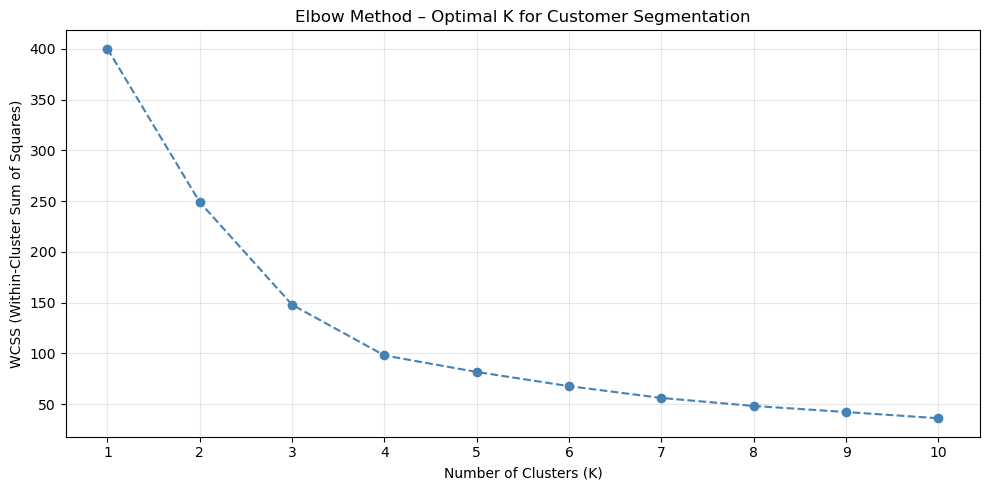

In [4]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='steelblue')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.title("Elbow Method – Optimal K for Customer Segmentation")
plt.xticks(list(k_range))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Apply K-Means with the Chosen K

Based on the elbow plot above we choose K = 5 — five distinct customer segments.

In [5]:
OPTIMAL_K = 5   # adjust if your elbow lands elsewhere

kmeans  = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"Customers per segment:")
print(df['Cluster'].value_counts().sort_index())

Customers per segment:
Cluster
0    42
1    39
2    59
3    29
4    31
Name: count, dtype: int64


## 5. Visualise the Segments

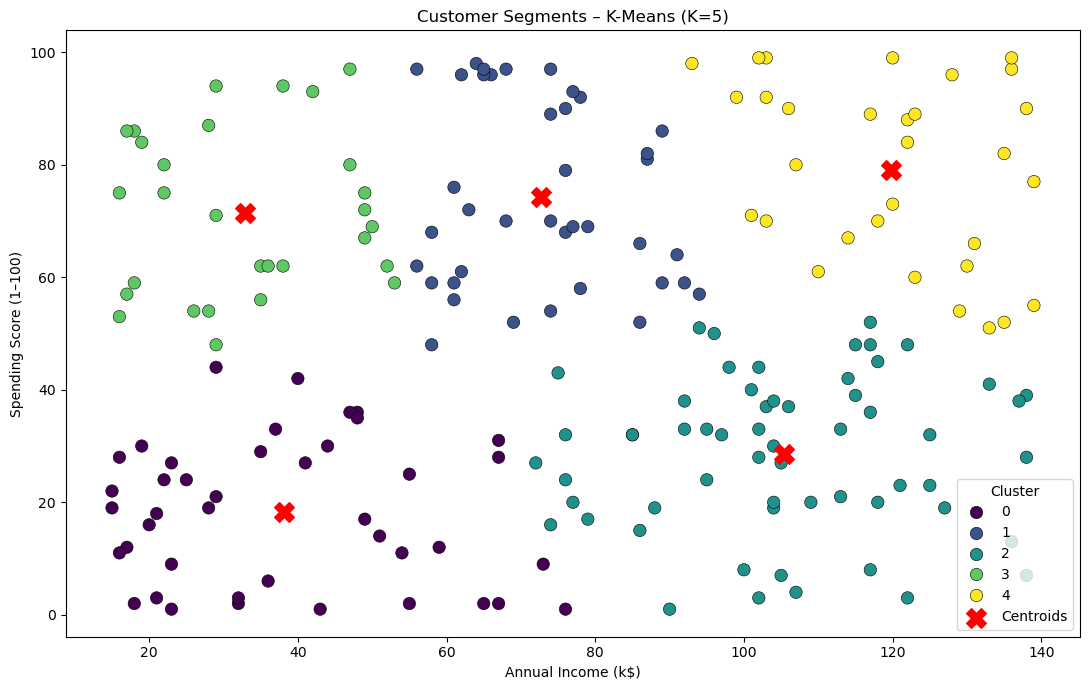

In [6]:
# Cluster centres in original (unscaled) space for interpretable annotations
centres = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=df,
    x='Annual_Income_k',
    y='Spending_Score',
    hue='Cluster',
    palette='viridis',
    s=80,
    edgecolor='k',
    linewidth=0.4
)
# Mark the centroids
plt.scatter(centres[:, 0], centres[:, 1],
            s=200, c='red', marker='X', label='Centroids', zorder=5)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1–100)")
plt.title(f"Customer Segments – K-Means (K={OPTIMAL_K})")
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## 6. Interpret the Segments

Give each cluster a business-friendly name based on its centroid's position:

In [7]:
segment_stats = df.groupby('Cluster')[['Annual_Income_k', 'Spending_Score']].mean().round(1)
segment_stats['Count'] = df['Cluster'].value_counts().sort_index()
print(segment_stats.to_string())
print("\nHint: High income + high spending → 'Premium' customers")
print("      Low income + high spending  → 'Impulsive' customers, etc.")

         Annual_Income_k  Spending_Score  Count
Cluster                                        
0                   38.1            18.2     42
1                   72.7            74.2     39
2                  105.4            28.5     59
3                   32.9            71.5     29
4                  119.8            79.1     31

Hint: High income + high spending → 'Premium' customers
      Low income + high spending  → 'Impulsive' customers, etc.
